## **Project Portfolio: Analisis Gaji Data Science (SQL + Python)**

## **Latar Belakang**
Project ini bertujuan untuk menganalisis tren gaji di industri Data Science mulai dari tahun 2020 hingga 2022. Analisis ini menggunakan dataset `ds_salaries.csv` dan dijalankan menggunakan **SQL Query** di dalam environment Python.

## **Business Questions**
Analisis ini akan menjawab pertanyaan strategis berikut:
1. **Salary Trend:** Bagaimana tren kenaikan gaji profesi data dari tahun ke tahun?
2. **Experience Impact:** Seberapa besar pengaruh level pengalaman terhadap besaran gaji?
3. **Remote Work:** Apakah bekerja secara Remote (WFH) lebih menguntungkan secara finansial dibanding WFO?
4. **Top Paying Roles:** Apa saja pekerjaan dengan rata-rata gaji tertinggi?

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

# Konfigurasi Visualisasi
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# 1. Load Data CSV
df = pd.read_csv('ds_salaries.csv')

# 2. Membuat Koneksi Database SQLite (Virtual)
conn = sqlite3.connect(':memory:')

# 3. Memasukkan dataframe ke dalam tabel SQL
df.to_sql('ds_salaries', conn, index=False, if_exists='replace')

print("Setup Berhasil! Database SQL siap digunakan.")
print(f"Total Data: {len(df)} baris")

Setup Berhasil! Database SQL siap digunakan.
Total Data: 607 baris


###  **Data Overview**
Sebelum melakukan analisis mendalam, kita akan melihat sampel data dan struktur kolom untuk memastikan tipe data sudah sesuai.

In [2]:
query_preview = "SELECT * FROM ds_salaries LIMIT 5"
df_preview = pd.read_sql_query(query_preview, conn)

display(df_preview)
print("\nInfo Tipe Data:")
df.info()

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L



Info Tipe Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          607 non-null    int64 
 1   work_year           607 non-null    int64 
 2   experience_level    607 non-null    object
 3   employment_type     607 non-null    object
 4   job_title           607 non-null    object
 5   salary              607 non-null    int64 
 6   salary_currency     607 non-null    object
 7   salary_in_usd       607 non-null    int64 
 8   employee_residence  607 non-null    object
 9   remote_ratio        607 non-null    int64 
 10  company_location    607 non-null    object
 11  company_size        607 non-null    object
dtypes: int64(5), object(7)
memory usage: 57.0+ KB


### **1. Analisis Tren Gaji (Salary Trend)**
**Pertanyaan:** Apakah rata-rata gaji di bidang Data Science mengalami kenaikan dari tahun 2020 ke 2022?

Kita akan menghitung rata-rata `salary_in_usd` yang dikelompokkan berdasarkan `work_year`.

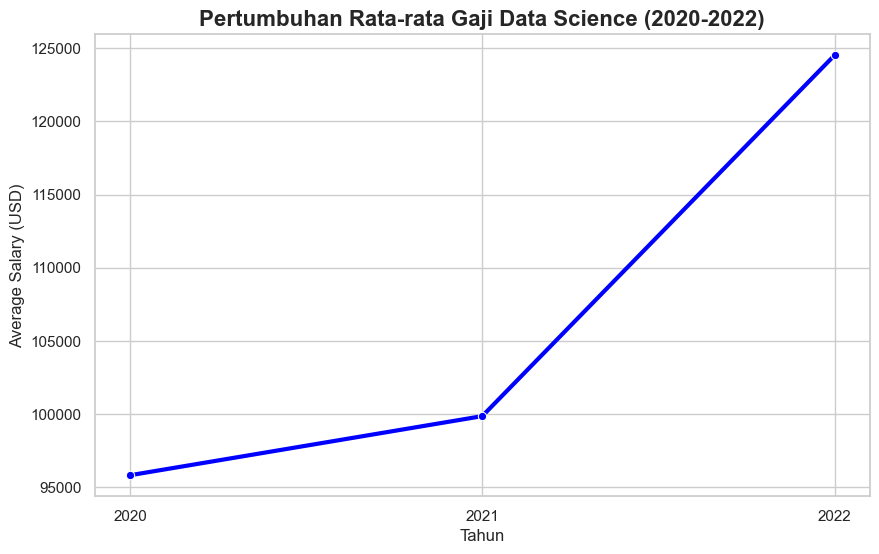

In [3]:
query_trend = """
SELECT
    work_year,
    AVG(salary_in_usd) as avg_salary
FROM ds_salaries
GROUP BY work_year
ORDER BY work_year ASC
"""

# Eksekusi Query
df_trend = pd.read_sql_query(query_trend, conn)

# Visualisasi Line Chart
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_trend, x='work_year', y='avg_salary', marker='o', linewidth=3, color='blue')
plt.title('Pertumbuhan Rata-rata Gaji Data Science (2020-2022)', fontsize=16, fontweight='bold')
plt.ylabel('Average Salary (USD)')
plt.xlabel('Tahun')
plt.xticks([2020, 2021, 2022])
plt.show()

### **2. Pengaruh Pengalaman terhadap Gaji**
**Pertanyaan:** Seberapa signifikan perbedaan gaji antara Junior, Mid-Level, Senior, dan Executive?

Kode Level:
* **EN:** Entry-level / Junior
* **MI:** Mid-level
* **SE:** Senior-level
* **EX:** Executive-level / Director

C:\Users\cahya\AppData\Local\Temp\ipykernel_19708\768309703.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_exp, x='experience_level', y='avg_salary', palette='viridis')


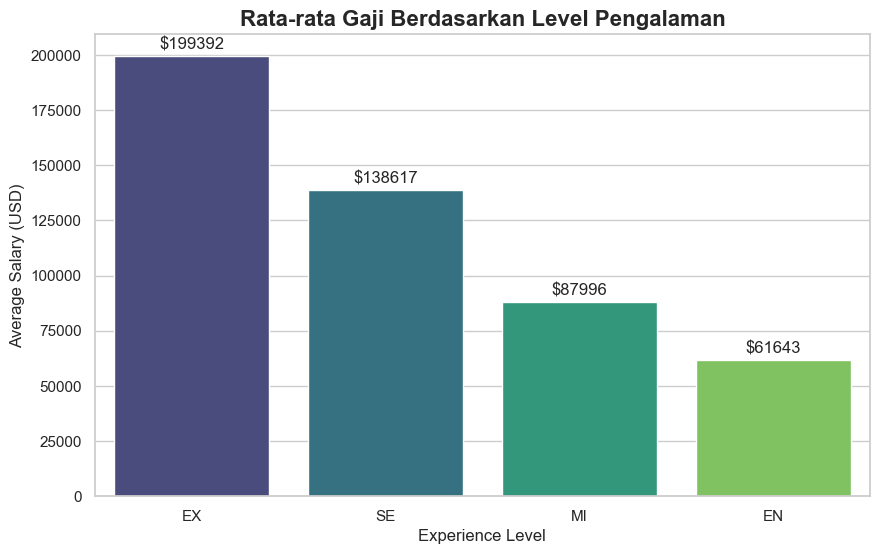

In [4]:
query_exp = """
SELECT
    experience_level,
    AVG(salary_in_usd) as avg_salary
FROM ds_salaries
GROUP BY experience_level
ORDER BY avg_salary DESC
"""

df_exp = pd.read_sql_query(query_exp, conn)

# Visualisasi Bar Chart
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_exp, x='experience_level', y='avg_salary', palette='viridis')
plt.title('Rata-rata Gaji Berdasarkan Level Pengalaman', fontsize=16, fontweight='bold')
plt.ylabel('Average Salary (USD)')
plt.xlabel('Experience Level')

# Menambah label angka di atas bar
for i in ax.containers:
    ax.bar_label(i, fmt='$%.0f', padding=3)

plt.show()

### **3. Remote Work vs WFO**
**Pertanyaan:** Apakah bekerja secara Full Remote memberikan kompensasi yang lebih baik dibandingkan WFO atau Hybrid?

Kategori:
* **0:** WFO (Work From Office)
* **50:** Hybrid
* **100:** Full Remote

C:\Users\cahya\AppData\Local\Temp\ipykernel_19708\3041088022.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_remote, x='remote_ratio', y='avg_salary', palette='magma')


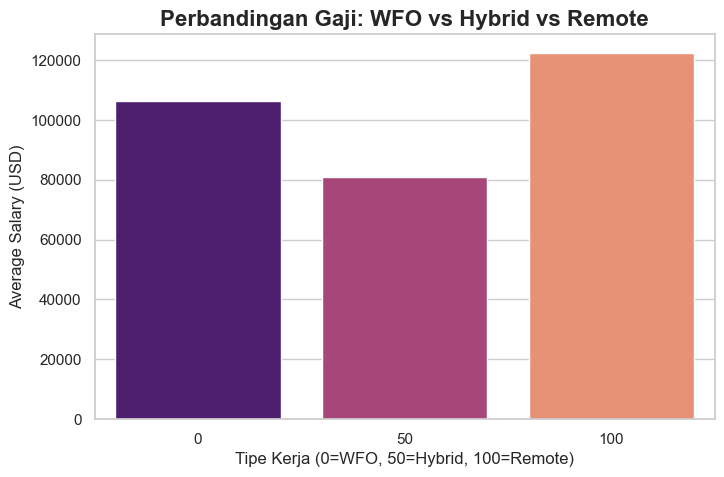

In [5]:
query_remote = """
SELECT
    remote_ratio,
    AVG(salary_in_usd) as avg_salary
FROM ds_salaries
GROUP BY remote_ratio
"""

df_remote = pd.read_sql_query(query_remote, conn)

# Visualisasi Bar Chart
plt.figure(figsize=(8, 5))
sns.barplot(data=df_remote, x='remote_ratio', y='avg_salary', palette='magma')
plt.title('Perbandingan Gaji: WFO vs Hybrid vs Remote', fontsize=16, fontweight='bold')
plt.xlabel('Tipe Kerja (0=WFO, 50=Hybrid, 100=Remote)')
plt.ylabel('Average Salary (USD)')
plt.show()

### **4. Top 5 Pekerjaan dengan Gaji Tertinggi**
**Pertanyaan:** Role apa saja yang memiliki rata-rata gaji tertinggi?

*Catatan: Kita memfilter pekerjaan yang minimal memiliki 3 data karyawan agar hasil rata-ratanya valid (tidak bias).*

C:\Users\cahya\AppData\Local\Temp\ipykernel_19708\2605292502.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_jobs, y='job_title', x='avg_salary', palette='coolwarm')


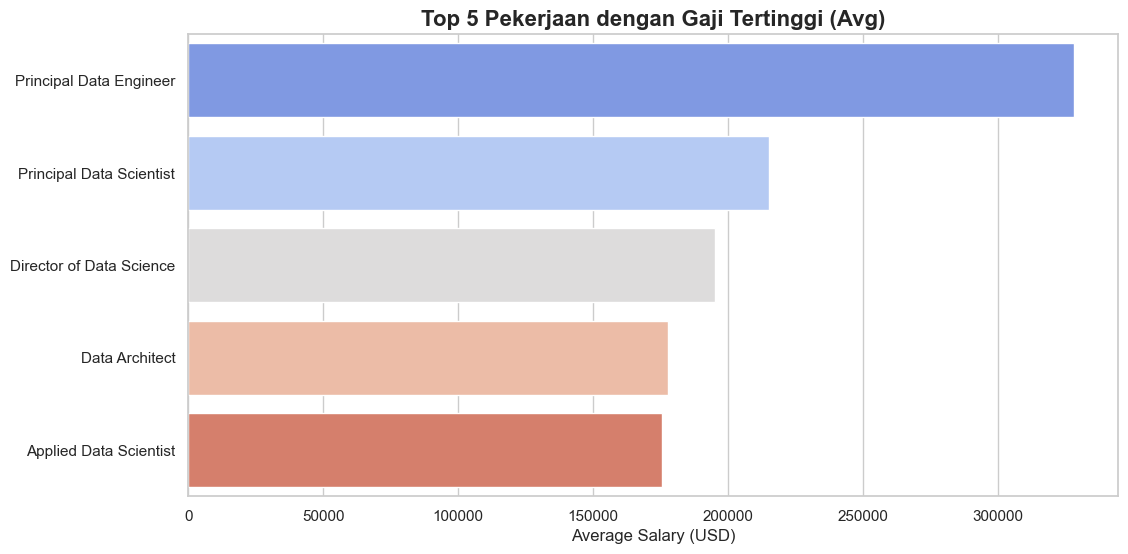

In [6]:
query_jobs = """
SELECT
    job_title,
    AVG(salary_in_usd) as avg_salary,
    COUNT(*) as total_employee
FROM ds_salaries
GROUP BY job_title
HAVING COUNT(*) >= 3
ORDER BY avg_salary DESC
LIMIT 5
"""

df_jobs = pd.read_sql_query(query_jobs, conn)

# Visualisasi Horizontal Bar Chart
plt.figure(figsize=(12, 6))
sns.barplot(data=df_jobs, y='job_title', x='avg_salary', palette='coolwarm')
plt.title('Top 5 Pekerjaan dengan Gaji Tertinggi (Avg)', fontsize=16, fontweight='bold')
plt.xlabel('Average Salary (USD)')
plt.ylabel('')
plt.show()

### **Kesimpulan Insight**
Berdasarkan analisis data di atas, kita dapat menyimpulkan:

1. **Tren Positif:** Industri data mengalami lonjakan gaji yang signifikan pada tahun 2022.
2. **Jenjang Karir:** Menjadi Senior (SE) atau Executive (EX) memberikan lompatan gaji yang sangat besar dibanding level Mid/Entry.
3. **Remote is King:** Bekerja secara Full Remote (100) ternyata memiliki rata-rata gaji tertinggi, kemungkinan dipengaruhi oleh perusahaan global yang merekrut talent dari berbagai negara dengan standar gaji tinggi.
4. **Role:** Posisi spesialis seperti *Principal Data Engineer* dan *Data Architect* menduduki peringkat atas gaji tertinggi.